<a href="https://colab.research.google.com/github/Hiraeth-mist/aging-muscle-transcriptomics-case-study/blob/main/notebooks/02_differential_expression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Differential Expression Analysis

## Objective

Identify age-associated gene expression changes across three skeletal muscle types:

- EDL
- Soleus
- TA

Differential expression analysis is performed using DESeq2 to compare aged and young mice within each muscle type.

## Expected Deliverables

- Differentially expressed genes
- Summary statistics
- DE gene tables
- Comparative visualization

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
install.packages("BiocManager")

BiocManager::install(c(
    "DESeq2",
    "ggplot2",
    "dplyr"
))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'DESeq2' 'ggplot2' 'dplyr'”
Old packages: 'callr', 'pak', 'sessioninfo', 'xtable'



In [2]:
library(DESeq2)
library(ggplot2)
library(dplyr)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The follo

In [3]:
dds <- readRDS(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/processed/dds.rds"
)

vsd <- readRDS(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/data/processed/vsd.rds"
)

In [4]:
colData(dds)

DataFrame with 18 rows and 3 columns
      sample_id   muscle      age
    <character> <factor> <factor>
ey1         ey1      EDL    Young
eo1         eo1      EDL    Old  
eo2         eo2      EDL    Old  
eo3         eo3      EDL    Old  
ey2         ey2      EDL    Young
...         ...      ...      ...
to2         to2       TA    Old  
to3         to3       TA    Old  
ty1         ty1       TA    Young
ty2         ty2       TA    Young
ty3         ty3       TA    Young

In [5]:
dds_edl <- dds[, dds$muscle == "EDL"]

dds_edl$age <- relevel(
    factor(dds_edl$age),
    ref = "Young"
)

design(dds_edl) <- ~ age

dds_edl <- DESeq(dds_edl)

estimating size factors

using 'avgTxLength' from assays(dds), correcting for library size

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [6]:
res_edl <- results(dds_edl)

summary(res_edl)


out of 11439 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 768, 6.7%
LFC < 0 (down)     : 851, 7.4%
outliers [1]       : 1, 0.0087%
low counts [2]     : 3327, 29%
(mean count < 21)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [7]:
res_edl_df <- as.data.frame(res_edl)

write.csv(
    res_edl_df,
    "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/EDL_DE_results.csv"
)

In [9]:
dds_sol <- dds[, dds$muscle == "Soleus"]
dds_sol$age <- relevel(
    factor(dds_sol$age),
    ref = "Young"
)

design(dds_sol) <- ~ age

dds_sol <- DESeq(dds_sol)

estimating size factors

using 'avgTxLength' from assays(dds), correcting for library size

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [10]:
res_sol <- results(dds_sol)

summary(res_sol)


out of 11439 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 53, 0.46%
LFC < 0 (down)     : 19, 0.17%
outliers [1]       : 5, 0.044%
low counts [2]     : 0, 0%
(mean count < 0)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [11]:
res_sol_df <- as.data.frame(res_sol)

write.csv(
    res_sol_df,
    "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/SOL_DE_results.csv"
)

In [12]:
dds_ta <- dds[, dds$muscle == "TA"]
dds_ta$age <- relevel(
    factor(dds_ta$age),
    ref = "Young"
)

design(dds_ta) <- ~ age

dds_ta <- DESeq(dds_ta)

estimating size factors

using 'avgTxLength' from assays(dds), correcting for library size

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



In [13]:
res_ta <- results(dds_ta)

summary(res_ta)


out of 11435 with nonzero total read count
adjusted p-value < 0.1
LFC > 0 (up)       : 93, 0.81%
LFC < 0 (down)     : 61, 0.53%
outliers [1]       : 5, 0.044%
low counts [2]     : 2439, 21%
(mean count < 6)
[1] see 'cooksCutoff' argument of ?results
[2] see 'independentFiltering' argument of ?results



In [14]:
res_ta_df <- as.data.frame(res_ta)

write.csv(
    res_ta_df,
    "/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/TA_DE_results.csv"
)

In [15]:
sig_edl <- subset(
    res_edl_df,
    padj < 0.05
)
nrow(sig_edl)

[1] 1129

In [16]:
sig_sol <- subset(
    res_sol_df,
    padj < 0.05
)
nrow(sig_sol)

[1] 44

In [17]:
sig_ta <- subset(
    res_ta_df,
    padj < 0.05
)
nrow(sig_ta)

[1] 105

In [19]:
up_edl <- subset(
    res_edl_df,
    padj < 0.05 &
    log2FoldChange > 1
)

nrow(up_edl)

down_edl <- subset(
    res_edl_df,
    padj < 0.05 &
    log2FoldChange < -1
)

nrow(down_edl)

[1] 204

[1] 226

In [21]:
up_sol <- subset(
    res_sol_df,
    padj < 0.05 &
    log2FoldChange > 1
)

down_sol <- subset(
    res_sol_df,
    padj < 0.05 &
    log2FoldChange < -1
)
nrow(up_sol)
nrow(down_sol)

[1] 29

[1] 11

In [22]:
up_ta <- subset(
    res_ta_df,
    padj < 0.05 &
    log2FoldChange > 1
)

down_ta <- subset(
    res_ta_df,
    padj < 0.05 &
    log2FoldChange < -1
)

In [23]:
nrow(up_edl)
nrow(down_edl)

nrow(up_sol)
nrow(down_sol)

nrow(up_ta)
nrow(down_ta)

[1] 204

[1] 226

[1] 29

[1] 11

[1] 53

[1] 15

In [24]:
deg_summary <- data.frame(
  Muscle = c("EDL","Soleus","TA"),
  Up = c(204,29,53),
  Down = c(226,11,15)
)

deg_summary

Muscle,Up,Down
<chr>,<dbl>,<dbl>
EDL,204,226
Soleus,29,11
TA,53,15


In [25]:
library(ggplot2)
library(tidyr)


Attaching package: ‘tidyr’


The following object is masked from ‘package:S4Vectors’:

    expand




In [26]:
deg_long <- pivot_longer(
  deg_summary,
  cols = c("Up","Down"),
  names_to = "Direction",
  values_to = "Count"
)

deg_long

Muscle,Direction,Count
<chr>,<chr>,<dbl>
EDL,Up,204
EDL,Down,226
Soleus,Up,29
Soleus,Down,11
TA,Up,53
TA,Down,15


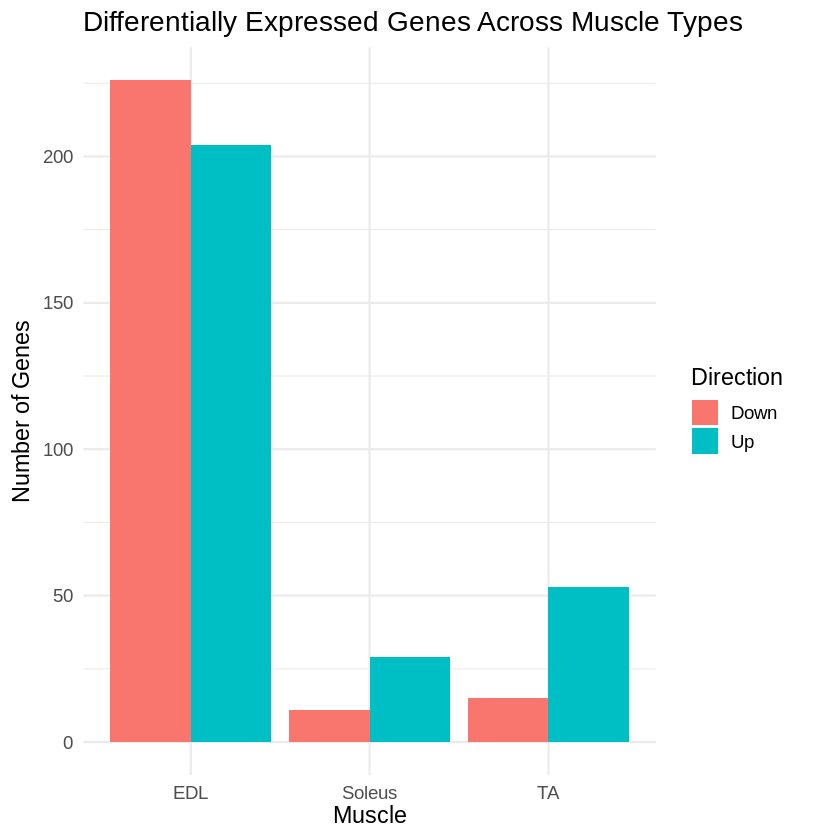

In [27]:
ggplot(
  deg_long,
  aes(
    x = Muscle,
    y = Count,
    fill = Direction
  )
) +
  geom_bar(
    stat = "identity",
    position = "dodge"
  ) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Differentially Expressed Genes Across Muscle Types",
    y = "Number of Genes"
  )

In [28]:
ggsave(
"/content/drive/MyDrive/aging-muscle-transcriptomics-case-study/results/DEG_summary_barplot.png",
width = 8,
height = 6,
dpi = 300
)